<a href="https://colab.research.google.com/github/marianagomez3108-spec/Facturacion/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [12]:
activos_proyecto = ["QCOM", "UNH", "KO"]



## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [15]:
import yfinance as yf

In [21]:
precios = yf.download(
    activos_proyecto,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  3 of 3 completed


Price           Close                               High              \
Ticker             KO        QCOM         UNH         KO        QCOM   
Date                                                                   
2024-01-02  55.309334  132.436523  508.214783  55.364811  134.297039   
2024-01-03  55.438778  129.952698  510.749603  55.660683  131.170998   
2024-01-04  55.253853  128.602142  513.943909  55.716151  129.697677   
2024-01-05  55.170647  129.131027  506.367950  55.429536  130.396566   
2024-01-08  55.577469  131.303207  505.557495  55.642190  131.416534   

Price                         Low                               Open  \
Ticker             UNH         KO        QCOM         UNH         KO   
Date                                                                   
2024-01-02  508.516265  54.246047  131.067112  496.275925  54.366245   
2024-01-03  515.234856  55.253858  129.376599  508.346717  55.411041   
2024-01-04  517.317324  55.161395  127.440505  511.663582  55.521987   
2024-01-05  515.432778  54.634383  128.299944  502.928568  55.290845   
2024-01-08  509.072219  54.939495  129.046036  497.529165  55.179892   

Price                                 Volume                    
Ticker            QCOM         UNH        KO     QCOM      UNH  
Date                                                            
2024-01-02  134.287600  496.436156  16322600  8495800  3415700  
2024-01-03  131.170998  511.701268  14830600  8133300  2891400  
2024-01-04  127.912717  513.548163  12912900  6770300  2994400  
2024-01-05  128.592713  515.432778  10412800  6827300  2815400  
2024-01-08  129.376590  508.271295  11554600  7729400  2648900

In [22]:
print("Dimensiones:", precios.shape)

precios.info()


Dimensiones: (502, 15)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, KO)     502 non-null    float64
 1   (Close, QCOM)   502 non-null    float64
 2   (Close, UNH)    502 non-null    float64
 3   (High, KO)      502 non-null    float64
 4   (High, QCOM)    502 non-null    float64
 5   (High, UNH)     502 non-null    float64
 6   (Low, KO)       502 non-null    float64
 7   (Low, QCOM)     502 non-null    float64
 8   (Low, UNH)      502 non-null    float64
 9   (Open, KO)      502 non-null    float64
 10  (Open, QCOM)    502 non-null    float64
 11  (Open, UNH)     502 non-null    float64
 12  (Volume, KO)    502 non-null    int64  
 13  (Volume, QCOM)  502 non-null    int64  
 14  (Volume, UNH)   502 non-null    int64  
dtypes: float64(12), int64(3)
memory usage: 62.8 KB


In [24]:
precios.describe()
precios.isna().sum()

Price   Ticker
Close   KO        0
        QCOM      0
        UNH       0
High    KO        0
        QCOM      0
        UNH       0
Low     KO        0
        QCOM      0
        UNH       0
Open    KO        0
        QCOM      0
        UNH       0
Volume  KO        0
        QCOM      0
        UNH       0
dtype: int64

In [25]:
cierre = precios["Close"]

cierre.head()


Ticker,KO,QCOM,UNH
Date,,,
2024-01-02,55.309334,132.436523,508.214783
2024-01-03,55.438778,129.952698,510.749603
2024-01-04,55.253853,128.602142,513.943909
2024-01-05,55.170647,129.131027,506.367950
2024-01-08,55.577469,131.303207,505.557495


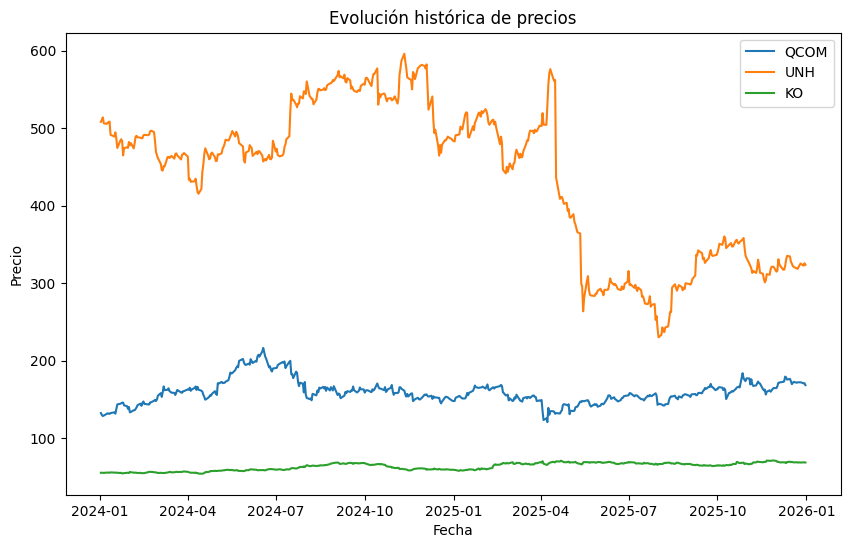

In [30]:
import matplotlib.pyplot as plt
#crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10,6))
for activo in activos_proyecto:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()

In [31]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()


Ticker,KO,QCOM,UNH
Date,,,
2024-01-02,100.000000,100.000000,100.000000
2024-01-03,100.234037,98.124516,100.498770
2024-01-04,99.899690,97.104740,101.127304
2024-01-05,99.749252,97.504090,99.636604
2024-01-08,100.484792,99.144257,99.477133


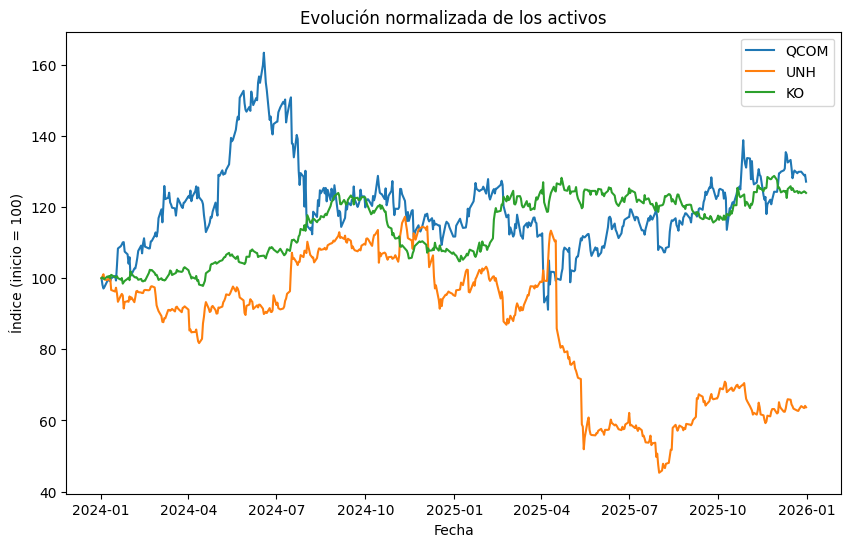

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

for activo in activos_proyecto:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()


## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

In [35]:
rendimientos = cierre.pct_change()

rendimientos.head()

Ticker,KO,QCOM,UNH
Date,,,
2024-01-02,NaN,NaN,NaN
2024-01-03,0.002340,-0.018755,0.004988
2024-01-04,-0.003336,-0.010393,0.006254
2024-01-05,-0.001506,0.004113,-0.014741
2024-01-08,0.007374,0.016822,-0.001601


In [36]:
rendimientos = rendimientos.dropna()

rendimientos.head()


Ticker,KO,QCOM,UNH
Date,,,
2024-01-03,0.002340,-0.018755,0.004988
2024-01-04,-0.003336,-0.010393,0.006254
2024-01-05,-0.001506,0.004113,-0.014741
2024-01-08,0.007374,0.016822,-0.001601
2024-01-09,-0.001830,0.006186,0.003448


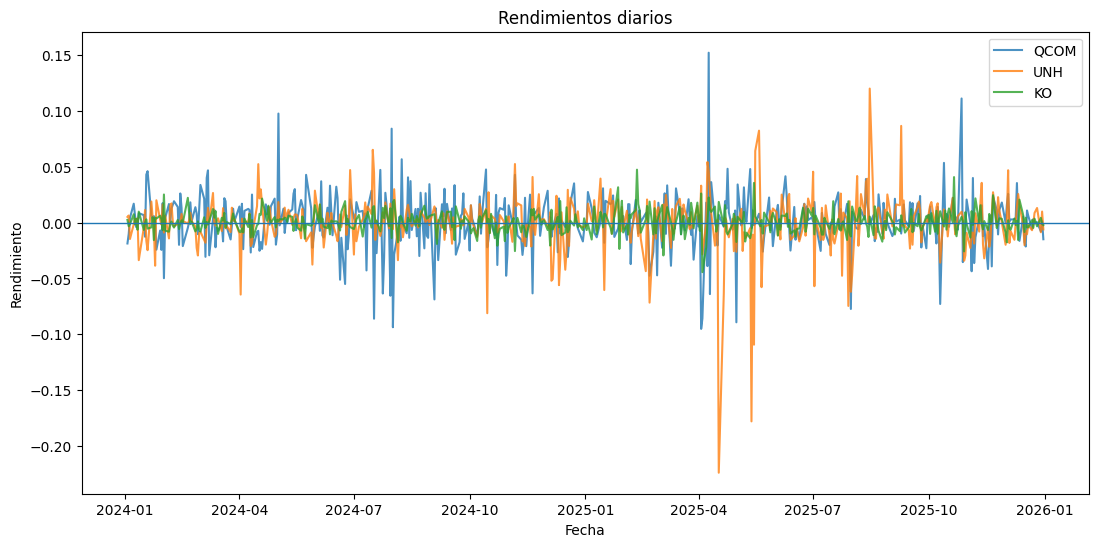

In [37]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos_proyecto:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()


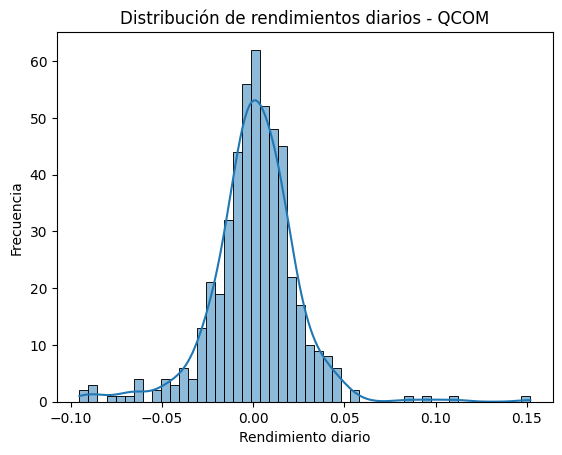

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=rendimientos,
    x="QCOM",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - QCOM")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()


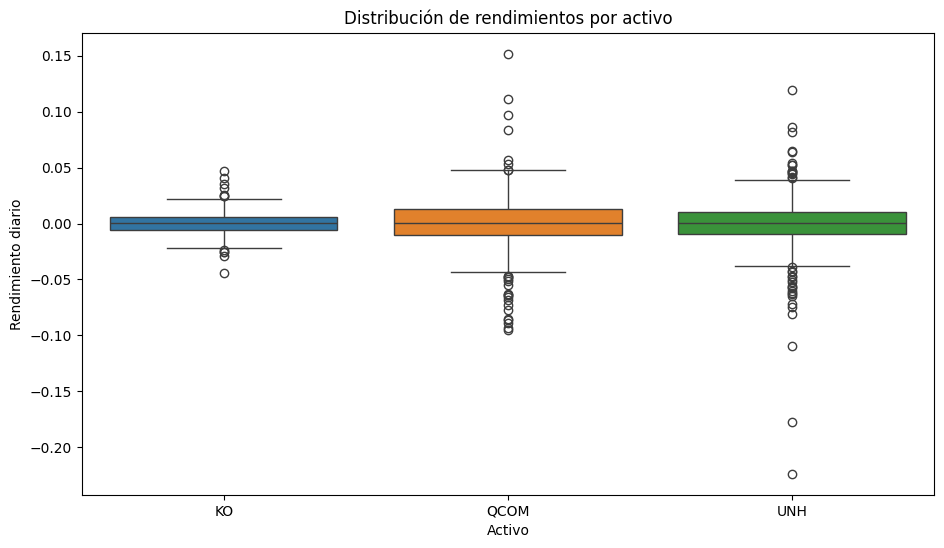

In [41]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()


In [42]:
correlacion = rendimientos.corr()

correlacion


Ticker,KO,QCOM,UNH
Ticker,,,
KO,1.000000,-0.062319,0.072084
QCOM,-0.062319,1.000000,0.083524
UNH,0.072084,0.083524,1.000000


## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

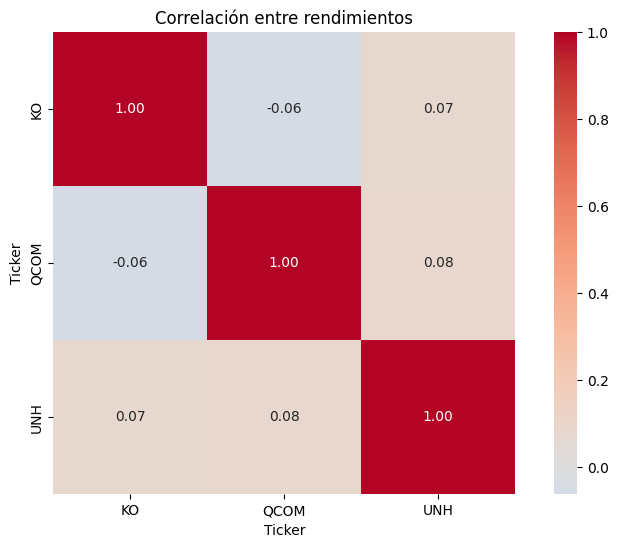

In [45]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()

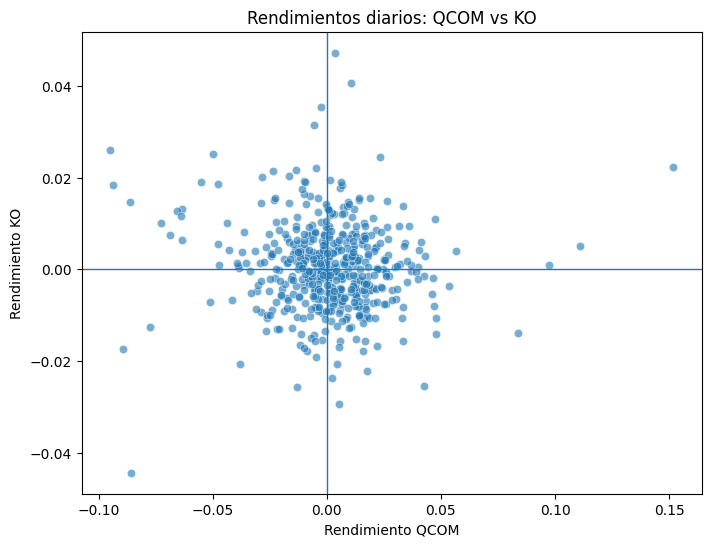

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="QCOM",
    y="KO",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: QCOM vs KO")
plt.xlabel("Rendimiento QCOM")
plt.ylabel("Rendimiento KO")

plt.show()


## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [49]:
import pandas as pd
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
KO,0.000476,0.000280,0.009635,-0.044411,0.047250
QCOM,0.000770,0.000879,0.024101,-0.095145,0.151853
UNH,-0.000591,0.000348,0.024345,-0.223797,0.119784
